# Retrieval diagnostics + recovered abundances (POSEIDON)


In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


# -----------------------------
# Paths (edit as needed)
# -----------------------------
CHI2_PATH = Path(r"chi2_log.csv")
TIMES_PATH = Path(r"Times")

POSEIDON_BASE_DIR = Path(r"POSEIDON_output/Trappist-1e/retrievals")
POSEIDON_OUT_CSV = POSEIDON_BASE_DIR / "retrieved_gases_recovered_minmax.csv"


# -----------------------------
# Plot style constants
# -----------------------------
PALETTE = {
    "uncontam": "#E9C46A",
    "contam": "#2A9D8F",
    "recon": "#E76F51",
}
MARKERS = {"uncontam": "o", "contam": "s", "recon": "D"}
LEGEND_LABELS = {"uncontam": "Chem", "contam": "Cont + Chem", "recon": "G-DAE + Chem"}

MODEL_ORDER = ["uncontam", "contam", "recon"]


## 1) Load and parse retrieval diagnostics

We parse model metadata from:
- `chi2_log.csv` → `model_name` (contains model type, transits, spot/facula fractions)
- `Times`        → `N_T`, `Mode`, `ffacfspot`, and runtime

Then we merge both on: `(n_transits, model_type, spot_fraction, facula_fraction)`.


In [2]:
MODEL_TYPE_RE = re.compile(r"(contam|recon|uncontam)")
N_TRANSITS_RE = re.compile(r"(\d+)T")
SPOT_RE = re.compile(r"(\d+\.\d+)spot")
FAC_RE = re.compile(r"(\d+\.\d+)fac")


def parse_model_name(model_name: str) -> Tuple[int | None, str | None, float, float]:
    """
    Parse metadata encoded in `model_name`.

    Expected patterns include tokens like:
    - "10T"
    - "contam" / "recon" / "uncontam"
    - "0.00spot"
    - "0.00fac"

    Returns
    -------
    n_transits, model_type, spot_fraction, facula_fraction
    """
    n_transits_match = N_TRANSITS_RE.search(model_name)
    n_transits = int(n_transits_match.group(1)) if n_transits_match else None

    model_type_match = MODEL_TYPE_RE.search(model_name)
    model_type = model_type_match.group(1) if model_type_match else None

    spot_match = SPOT_RE.search(model_name)
    spot_fraction = float(spot_match.group(1)) if spot_match else 0.0

    fac_match = FAC_RE.search(model_name)
    facula_fraction = float(fac_match.group(1)) if fac_match else 0.0

    return n_transits, model_type, spot_fraction, facula_fraction


def parse_ffacfspot(ffacfspot: str) -> Tuple[float, float]:
    """
    Parse the 'ffacfspot' token formatted as "facula-spot".
    """
    parts = ffacfspot.split("-")
    facula_fraction = float(parts[0])
    spot_fraction = float(parts[1])
    return facula_fraction, spot_fraction


# --- Load chi2_log.csv ---
chi2_df = pd.read_csv(CHI2_PATH)

chi2_df[["n_transits", "model_type", "spot_fraction", "facula_fraction"]] = (
    chi2_df["model_name"].apply(lambda x: pd.Series(parse_model_name(str(x))))
)

# --- Load Times ---
times_df = pd.read_csv(TIMES_PATH, sep=r"\s+", engine="python")

times_df["Mode"] = times_df["Mode"].astype(str).str.replace('"', "", regex=False)

times_df[["facula_fraction", "spot_fraction"]] = (
    times_df["ffacfspot"].astype(str).apply(lambda x: pd.Series(parse_ffacfspot(x)))
)

times_df = times_df.rename(
    columns={
        "N_T": "n_transits",
        "Mode": "model_type",
        "Time": "retrieval_time_min",
    }
).drop(columns=["ffacfspot"])

# --- Merge ---
merged_df = pd.merge(
    chi2_df,
    times_df,
    on=["n_transits", "model_type", "spot_fraction", "facula_fraction"],
    how="left",
)

merged_df.head()


,planet_name,model_name,dof,chi2,chi2_reduced,N,p,MSE,observation,n_transits,model_type,spot_fraction,facula_fraction,retrieval_time_min
0,Trappist-1e,recon_10T_0.08spot-0.54fac,374,140.481671,0.375619,385,11,3.565349e-10,NaN,10,recon,0.08,0.54,9.53
1,Trappist-1e,recon_10T_0.26spot-0.70fac,374,131.115889,0.350577,385,11,3.308338e-10,NaN,10,recon,0.26,0.70,10.23
2,Trappist-1e,recon_10T_0.01spot-0.08fac,374,133.372519,0.356611,385,11,3.449145e-10,NaN,10,recon,0.01,0.08,9.23
3,Trappist-1e,recon_10T_0.00spot-0.00fac,374,130.982987,0.350222,385,11,3.296390e-10,NaN,10,recon,0.00,0.00,9.89
4,Trappist-1e,recon_100T_0.00spot-0.00fac,374,1267.056967,3.387853,385,11,3.208474e-10,NaN,100,recon,0.00,0.00,20.18


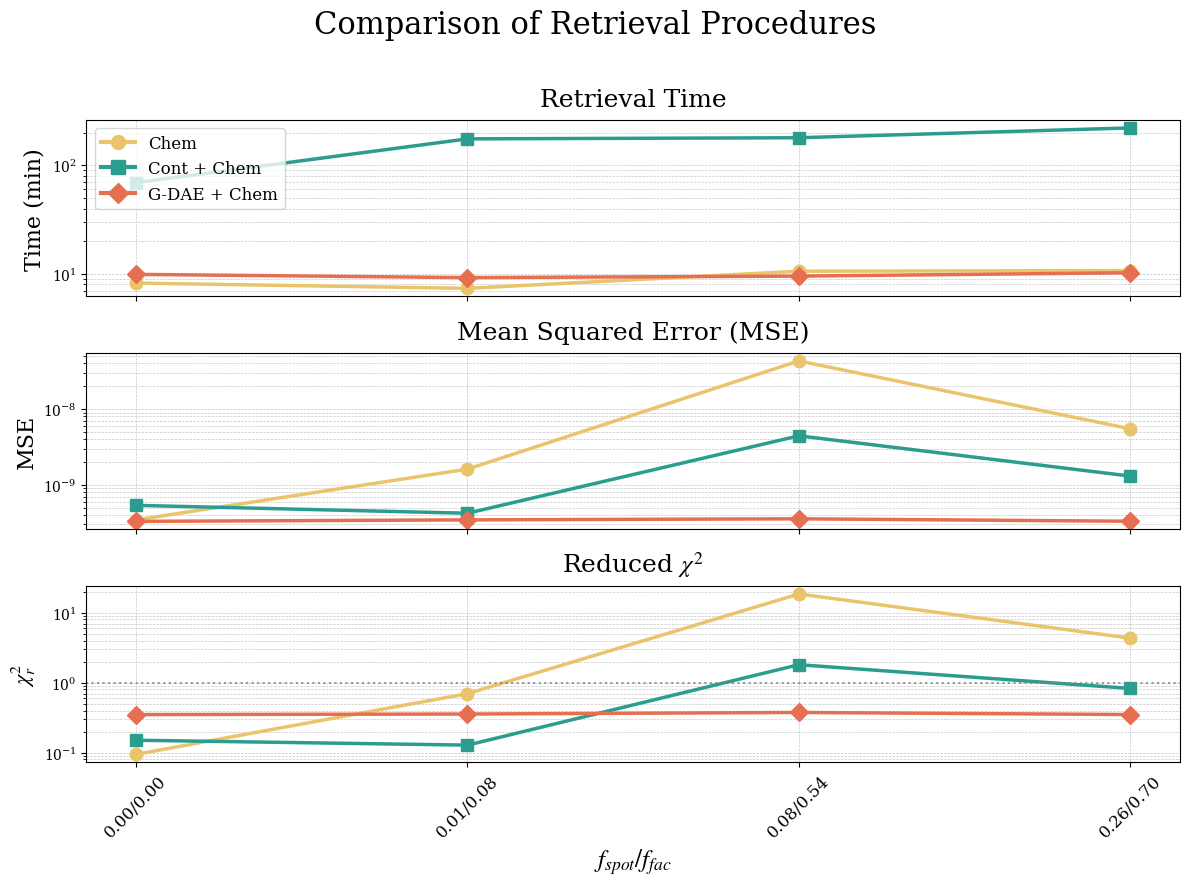

In [7]:
LINE_WIDTH = 2.5
MARKER_SIZE = 9


def make_ratio_label(row: pd.Series) -> str:
    """
    X-axis label in the form: 'spot/facula' with 2 decimals.
    """
    return f"{row['spot_fraction']:.2f}/{row['facula_fraction']:.2f}"


merged_df = merged_df.copy()
merged_df["x_label"] = merged_df.apply(make_ratio_label, axis=1)

x_labels = sorted(
    merged_df["x_label"].unique().tolist(),
    key=lambda s: (float(s.split("/")[0]), float(s.split("/")[1])),
)
x_ticks = np.arange(len(x_labels))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Comparison of Retrieval Procedures", fontsize=22)

for model_type in MODEL_ORDER:
    model_df = merged_df[merged_df["model_type"] == model_type].copy()
    if model_df.empty:
        continue

    color = PALETTE[model_type]
    marker = MARKERS[model_type]

    sub_10 = model_df[model_df["n_transits"] == 10]
    if sub_10.empty:
        continue

    cols = ["retrieval_time_min", "MSE", "chi2_reduced"]
    df_10t = (
        sub_10.groupby("x_label")[cols]
        .mean()
        .reindex(x_labels)
        .reset_index()
    )

    if df_10t["retrieval_time_min"].isnull().all():
        continue

    axes[0].plot(
        x_ticks,
        df_10t["retrieval_time_min"],
        color=color,
        linestyle="-",
        marker=marker,
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
    )
    axes[0].set_yscale("log")
    axes[1].plot(
        x_ticks,
        df_10t["MSE"],
        color=color,
        linestyle="-",
        marker=marker,
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
    )
    axes[2].plot(
        x_ticks,
        df_10t["chi2_reduced"],
        color=color,
        linestyle="-",
        marker=marker,
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
    )

# Axes formatting
axes[0].set_ylabel("Time (min)", fontsize=16)
axes[0].set_title("Retrieval Time", pad=10, fontsize=18)
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

axes[1].set_ylabel("MSE", fontsize=16)
axes[1].set_title("Mean Squared Error (MSE)", pad=10, fontsize=18)
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

axes[2].set_ylabel(r"$\chi^2_r$", fontsize=16)
axes[2].set_title(r"Reduced $\chi^2$", fontsize=18, pad=10)
axes[2].set_yscale("log")
axes[2].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes[2].axhline(1.0, color="gray", lw=1.5, ls=":", alpha=0.8)

axes[2].set_xlabel(r"$f_{spot} / f_{fac}$", fontsize=18)
axes[2].set_xticks(x_ticks)
axes[2].set_xticklabels(x_labels, rotation=45, fontsize=12)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=PALETTE[m],
        lw=3,
        marker=MARKERS[m],
        markersize=10,
        label=LEGEND_LABELS[m],
    )
    for m in MODEL_ORDER
]
axes[0].legend(handles=legend_handles, fontsize=12, loc="upper left")

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("exp0-retrieval_comparison_03-comp.png", dpi=500, bbox_inches="tight")
plt.show()


## 3) Parse POSEIDON `*_results.txt` files

Goal:
- Extract `Model:` metadata (type, transits, spot/facula)
- Extract `log_{gas} = value (+plus)(-minus)` lines from the 1σ constraints block
- Save a tidy CSV with recovered values and min/max 1σ bounds

In [4]:
NUM_RE = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?"

MODEL_REGEX = re.compile(
    r"^(?P<model_type>contam|recon|uncontam)_"
    r"(?P<n_transits>\d+)T_"
    r"(?P<spot_fraction>\d+(?:\.\d+)?)spot-"
    r"(?P<facula_fraction>\d+(?:\.\d+)?)fac$"
)

PARAM_LINE_1SIGMA = re.compile(
    rf"^\s*log_(?P<gas>H2O|CH4|CO2|O3)\s*=\s*(?P<val>{NUM_RE})\s*"
    rf"\(\+(?P<plus>{NUM_RE})\)\s*\(\-(?P<minus>{NUM_RE})\)\s*$"
)


def read_text_safely(path: Path) -> str:
    """
    Read text with a few common encodings (handles sigma and other symbols robustly).
    """
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=encoding)
        except Exception:
            continue
    return path.read_bytes().decode("latin-1", errors="ignore")


def parse_model_block(text: str) -> Dict[str, object]:
    """
    Extract the 'Model:' line and parse it if it matches the standard pattern.
    """
    model_name = None
    for line in text.splitlines():
        if line.strip().startswith("Model:"):
            model_name = line.split("Model:", 1)[1].strip()
            break

    meta: Dict[str, object] = {"model_name": model_name}
    if model_name:
        match = MODEL_REGEX.match(model_name)
        if match:
            meta.update(
                {
                    "model_type": match.group("model_type"),
                    "n_transits": int(match.group("n_transits")),
                    "spot_fraction": float(match.group("spot_fraction")),
                    "facula_fraction": float(match.group("facula_fraction")),
                }
            )
        else:
            meta.update(
                {
                    "model_type": None,
                    "n_transits": np.nan,
                    "spot_fraction": np.nan,
                    "facula_fraction": np.nan,
                }
            )
    else:
        meta.update(
            {
                "model_type": None,
                "n_transits": np.nan,
                "spot_fraction": np.nan,
                "facula_fraction": np.nan,
            }
        )
    return meta


def find_block_lines_1sigma(text: str) -> List[str]:
    """
    Locate the '1 sigma constraints' block without depending on the literal 'σ'.

    Strategy:
    - find a line starting with '1' and containing 'constraints' (case-insensitive)
    - then advance to the first line containing '='
    - collect subsequent lines until a blank or separator is found
    """
    lines = text.splitlines()
    header_pat = re.compile(r"^\s*1[^\n]*constraints\b", flags=re.IGNORECASE)

    start_idx = None
    for i, line in enumerate(lines):
        if header_pat.search(line):
            start_idx = i
            break
    if start_idx is None:
        return []

    i = start_idx + 1
    while i < len(lines) and "=" not in lines[i]:
        i += 1

    collected: List[str] = []
    while i < len(lines):
        s = lines[i].strip()
        if (not s) or s.startswith(("***", "###", "---", "___")):
            break
        collected.append(s)
        i += 1

    return collected


def parse_params_from_lines(lines: List[str]) -> Dict[str, Dict[str, float]]:
    """
    Parse lines of the form: 'log_CO2 = -2.32 (+0.23)(-0.26)' into value and 1σ min/max.
    """
    out: Dict[str, Dict[str, float]] = {}
    for line in lines:
        match = PARAM_LINE_1SIGMA.match(line)
        if not match:
            continue

        gas = match.group("gas")
        val = float(match.group("val"))
        plus = float(match.group("plus"))
        minus = float(match.group("minus"))

        out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}

    return out


def fallback_parse_smallest_uncertainty(text: str) -> Dict[str, Dict[str, float]]:
    """
    Fallback: scan the full file for parameter lines and keep the tightest
    uncertainty per gas (minimizing |plus| + |minus|).
    """
    out: Dict[str, Dict[str, float]] = {}
    best_errsum: Dict[str, float] = {}

    for raw_line in text.splitlines():
        match = PARAM_LINE_1SIGMA.match(raw_line.strip())
        if not match:
            continue

        gas = match.group("gas")
        val = float(match.group("val"))
        plus = float(match.group("plus"))
        minus = float(match.group("minus"))

        errsum = abs(plus) + abs(minus)
        if (gas not in best_errsum) or (errsum < best_errsum[gas]):
            best_errsum[gas] = errsum
            out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}

    return out


def parse_poseidon_file(path: Path) -> Dict[str, object]:
    """
    Parse one POSEIDON *_results.txt file into a flat row.
    """
    text = read_text_safely(path)
    meta = parse_model_block(text)

    block_lines = find_block_lines_1sigma(text)
    one_sigma = parse_params_from_lines(block_lines)

    if not one_sigma:
        one_sigma = fallback_parse_smallest_uncertainty(text)

    row: Dict[str, object] = {"file": str(path)}
    row.update(meta)

    for gas in ["CO2", "CH4", "O3", "H2O"]:
        g = one_sigma.get(gas, {})
        row[f"log_{gas}"] = g.get("val", np.nan)
        row[f"log_{gas}_min1s"] = g.get("min1s", np.nan)
        row[f"log_{gas}_max1s"] = g.get("max1s", np.nan)

    return row


def collect_poseidon_results(base_dir: Path) -> pd.DataFrame:
    """
    Recursively parse all '*_results.txt' under base_dir.
    """
    files = sorted(base_dir.rglob("*_results.txt"))
    rows = [parse_poseidon_file(p) for p in files]
    df_out = pd.DataFrame(rows)

    meta_cols = [
        "file",
        "model_name",
        "model_type",
        "n_transits",
        "spot_fraction",
        "facula_fraction",
    ]
    gas_cols: List[str] = []
    for gas in ["CO2", "CH4", "O3", "H2O"]:
        gas_cols.extend([f"log_{gas}", f"log_{gas}_min1s", f"log_{gas}_max1s"])

    ordered = [c for c in meta_cols if c in df_out.columns] + [
        c for c in gas_cols if c in df_out.columns
    ]
    others = [c for c in df_out.columns if c not in ordered]
    df_out = df_out[ordered + others]

    if "n_transits" in df_out.columns:
        df_out["n_transits"] = df_out["n_transits"].astype("Int64")

    for col in ["spot_fraction", "facula_fraction"]:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors="coerce")

    return df_out


In [5]:
poseidon_df = collect_poseidon_results(POSEIDON_BASE_DIR)
poseidon_df.to_csv(POSEIDON_OUT_CSV, index=False)

print(f"Files parsed: {len(poseidon_df)}")
print(f"CSV saved to: {POSEIDON_OUT_CSV}")
print()
print(poseidon_df.head(12).to_string(index=False))

poseidon_df = poseidon_df.dropna()
poseidon_df.head()

Files parsed: 34
CSV saved to: POSEIDON_output\Trappist-1e\retrievals\retrieved_gases_recovered_minmax.csv

                                                                                   file                   model_name model_type  n_transits  spot_fraction  facula_fraction  log_CO2  log_CO2_min1s  log_CO2_max1s  log_CH4  log_CH4_min1s  log_CH4_max1s  log_O3  log_O3_min1s  log_O3_max1s  log_H2O  log_H2O_min1s  log_H2O_max1s
POSEIDON_output\Trappist-1e\retrievals\results\contam_100T_0.00spot-0.00fac_results.txt contam_100T_0.00spot-0.00fac     contam         100           0.00             0.00    -2.57          -2.67          -2.47    -7.22          -7.44          -7.04   -7.61         -7.88         -7.26    -7.20          -7.64          -6.80
POSEIDON_output\Trappist-1e\retrievals\results\contam_100T_0.01spot-0.08fac_results.txt contam_100T_0.01spot-0.08fac     contam         100           0.01             0.08    -2.77          -2.87          -2.67    -7.04          -7.23        

,file,model_name,model_type,n_transits,spot_fraction,facula_fraction,log_CO2,log_CO2_min1s,log_CO2_max1s,log_CH4,log_CH4_min1s,log_CH4_max1s,log_O3,log_O3_min1s,log_O3_max1s,log_H2O,log_H2O_min1s,log_H2O_max1s
0,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.00spot-0.00fac,contam,100,0.00,0.00,-2.57,-2.67,-2.47,-7.22,-7.44,-7.04,-7.61,-7.88,-7.26,-7.20,-7.64,-6.80
1,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.01spot-0.08fac,contam,100,0.01,0.08,-2.77,-2.87,-2.67,-7.04,-7.23,-6.88,-7.62,-7.87,-7.26,-7.86,-7.96,-7.69
2,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.08spot-0.54fac,contam,100,0.08,0.54,-4.06,-4.14,-3.97,-6.27,-6.35,-6.19,-6.96,-7.29,-6.70,-7.97,-7.99,-7.93
3,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.26spot-0.70fac,contam,100,0.26,0.70,-2.23,-2.30,-2.16,-4.84,-4.89,-4.79,-2.26,-2.34,-2.18,-7.70,-7.91,-7.36
4,POSEIDON_output\Trappist-1e\retrievals\results...,contam_10T_0.00spot-0.00fac,contam,10,0.00,0.00,-2.84,-3.15,-2.52,-7.12,-7.61,-6.72,-7.05,-7.66,-6.43,-6.50,-7.22,-5.98


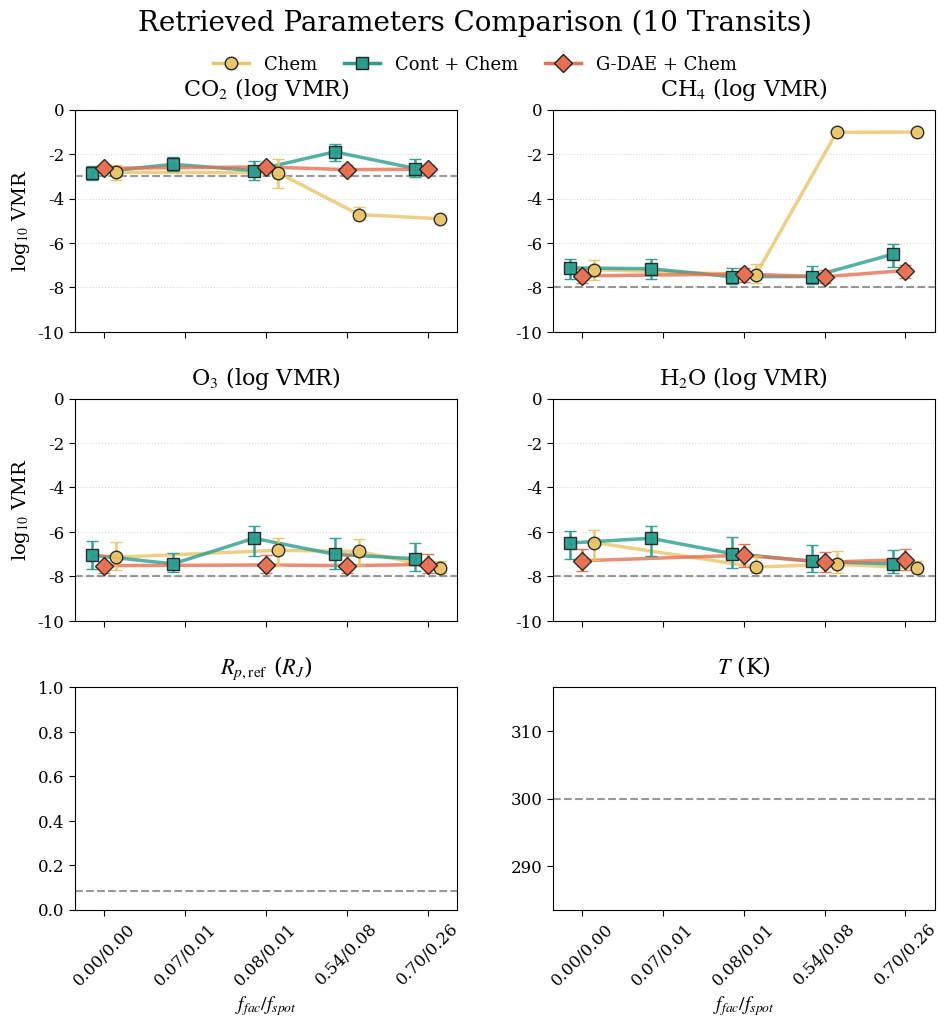

In [6]:
LINE_WIDTH = 2.5
MARKER_SIZE = 9
EDGE_COLOR = "#222222"
ERROR_BAR_WIDTH = 1.8

FAM_OFFSETS = {"contam": -0.15, "recon": 0.0, "uncontam": +0.15}
EXPECTED = {"log_CO2": -3.0, "log_CH4": -8.0, "log_O3": -8.0, "log_H2O": -8.0, "R_p_ref": 0.0821, "T": 300.0}

PARAM_TITLES = {
    "log_CO2": r"CO$_2$ (log VMR)",
    "log_CH4": r"CH$_4$ (log VMR)",
    "log_O3": r"O$_3$ (log VMR)",
    "log_H2O": r"H$_2$O (log VMR)",
    "R_p_ref": r"$R_{p,\mathrm{ref}}$ ($R_J$)",
    "T": r"$T$ (K)"
}
PARAMS_TO_PLOT = ["log_CO2", "log_CH4", "log_O3", "log_H2O", "R_p_ref", "T"]

plot_df = poseidon_df[poseidon_df["n_transits"] == 10].copy()
if plot_df.empty:
    print("Warning: filtered DataFrame is empty (n_transits == 10). Check inputs.")

plot_df["ratio"] = (
    plot_df["facula_fraction"].map(lambda v: f"{v:.2f}")
    + "/"
    + plot_df["spot_fraction"].map(lambda v: f"{v:.2f}")
)

order = sorted(plot_df["ratio"].astype(str).unique())
pos_map = {lab: i for i, lab in enumerate(order)}
plot_df["xpos"] = plot_df["ratio"].map(pos_map)


def plot_param_panel(ax: plt.Axes, param: str, data: pd.DataFrame) -> None:
    """
    Plot recovered values for one parameter with asymmetric 1σ error bars.
    """
    y = param
    y_min = f"{param}_min1s"
    y_max = f"{param}_max1s"

    if param in EXPECTED:
        ax.axhline(
            EXPECTED[param],
            linestyle="--",
            linewidth=1.5,
            color="#555",
            alpha=0.6,
            zorder=1,
            label="True Value"
        )

    if y not in data.columns:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    gdf = data[np.isfinite(data[y])].copy()
    if gdf.empty:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", alpha=0.5, linestyle=":", linewidth=0.8)

    for fam in MODEL_ORDER:
        sub = gdf[gdf["model_type"] == fam]
        if sub.empty:
            continue

        color = PALETTE.get(fam, "#555")
        marker = MARKERS.get(fam, "o")

        sub = sub.sort_values("xpos")
        x = sub["xpos"].to_numpy(dtype=float) + FAM_OFFSETS.get(fam, 0.0)
        yv = sub[y].to_numpy(dtype=float)

        if (y_min in sub.columns) and (y_max in sub.columns):
            yerr_low = yv - sub[y_min].to_numpy(dtype=float)
            yerr_up = sub[y_max].to_numpy(dtype=float) - yv
            yerr = np.vstack([yerr_low, yerr_up])
        else:
            yerr = np.zeros((2, len(yv)))

        if len(x) > 1:
            ax.plot(
                x,
                yv,
                linestyle="-",
                linewidth=LINE_WIDTH,
                color=color,
                alpha=0.8,
                zorder=2,
            )

        ax.errorbar(
            x,
            yv,
            yerr=yerr,
            fmt=marker,
            ms=MARKER_SIZE,
            capsize=4,
            capthick=ERROR_BAR_WIDTH * 0.8,
            elinewidth=ERROR_BAR_WIDTH,
            color=color,
            markerfacecolor=color,
            markeredgecolor=EDGE_COLOR,
            markeredgewidth=1.0,
            linestyle="None",
            label=LEGEND_LABELS.get(fam, fam),
            alpha=0.95,
            zorder=3,
        )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=0, ha="center")


fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex="col")
fig.subplots_adjust(
    top=0.88,
    bottom=0.08,
    left=0.10,
    right=0.96,
    wspace=0.25,
    hspace=0.30,
)
fig.suptitle("Retrieved Parameters Comparison (10 Transits)", fontsize=20, y=0.98)

axes_flat = axes.ravel()
for ax, param in zip(axes_flat, PARAMS_TO_PLOT):
    plot_param_panel(ax, param, plot_df)
    ax.set_title(PARAM_TITLES[param], fontsize=16, pad=10)

y_bottom, y_top = -10, 0
y_ticks = np.arange(0, -12, -2)

for i in range(2):
    for j in range(2):
        axes[i, j].set_ylim(y_bottom, y_top)
        axes[i, j].set_yticks(y_ticks)
        axes[i, j].tick_params(labelsize=12, length=4)

        if j == 0:
            axes[i, j].set_ylabel(r"log$_{10}$ VMR", fontsize=14)

# For the third row (R_p_ref and T)
for j in range(2):
    axes[2, j].tick_params(labelsize=12, length=4)
    axes[2, j].set_xlabel(r"$f_{fac}/f_{spot}$", fontsize=14)
    axes[2, j].tick_params(axis="x", rotation=45)

for ax in axes[:, 0]:
    ax.tick_params(axis="y", labelleft=True)
for ax in axes[:, 1]:
    ax.tick_params(axis="y", labelleft=True) # Ensure right column has ticks unhidden
for ax in axes[0:2, :].ravel():
    ax.tick_params(axis="x", labelbottom=False)
for ax in axes[2, :]:
    ax.tick_params(axis="x", labelbottom=True)

present_fams = [m for m in MODEL_ORDER if m in plot_df["model_type"].unique()]
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=MARKERS[f],
        linestyle="-",
        linewidth=LINE_WIDTH,
        color=PALETTE[f],
        markerfacecolor=PALETTE[f],
        markeredgecolor=EDGE_COLOR,
        markeredgewidth=1.0,
        markersize=MARKER_SIZE,
        label=LEGEND_LABELS[f],
    )
    for f in present_fams
]

if legend_handles:
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.90),
        ncols=len(legend_handles),
        frameon=False,
        columnspacing=1.5,
        handlelength=2.0,
        fontsize=13,
    )

#plt.savefig("exp0-retrieval-mixratio-v2-comp.png", dpi=500, bbox_inches="tight")
plt.show()